<div>
    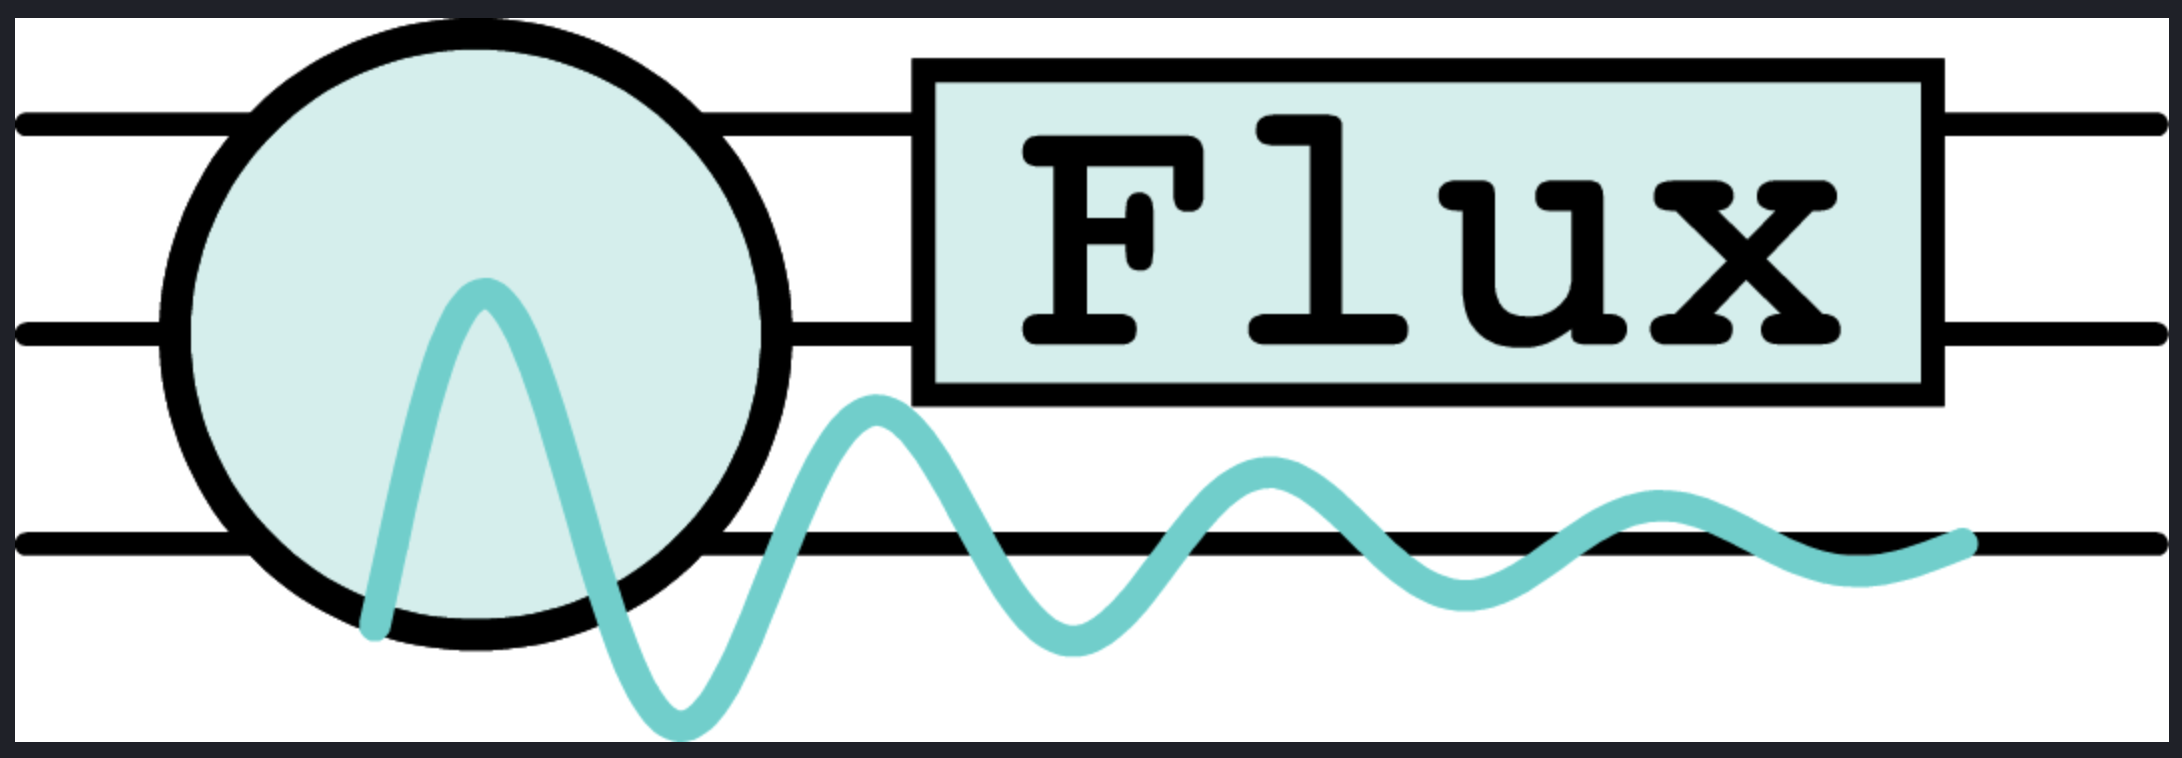
</div>

# Installation: Run the following cell to install QFlux in Colab

In [ ]:
!pip install qflux

# **QFlux Tutorial**

<h2> This notebook implements codes referenced in the Supporting Information for: </h2>

<h2>
<b> QFlux: Classical Foundations for Quantum Dynamics Simulation </b>
</h2>

<h2> <b> Part I - Building Intuition and Computational Workflow</b> </h2>

<h3>
    <b> Authors: </b> <br><br>
Brandon C. Allen, Xiaohan Dan, Delmar G. A. Cabral, Nam P. Vu, Cameron Cianci, Alexander V. Soudackov, Rishab Dutta, Sabre Kais, Eitan Geva, and Victor S. Batista</h3>

**Note:** Each section builds on the previous ones. **Execute the cells sequentially**, as later sections rely on functions and data defined earlier.

# Table of Contents
$ \newcommand{\ii}{{\kern0.5pt \mathrm{i} \kern0.5pt }}$

* Section 2

  - <a href="#ScriptSpt2pt1">Script S.2.1: Harmonic Oscillator Dynamics With QuTiP</a>

  - <a href="#ScriptSpt2pt2">Script S.2.2: Expectation Values For The Harmonic Oscillator</a>

* Section 3

  - <a href="#ScriptSpt3pt1">Script S.3.1: Coherent State Wavepacket Initialization</a>

  - <a href="#ScriptSpt3pt2">Script S.3.2: SOFT Operators For Harmonic Oscillator</a>

  - <a href="#ScriptSpt3pt3">Script S.3.3: SOFT Propagation</a>

  - <a href="#ScriptSpt3pt4">Script S.3.4: Harmonic Oscillator Expectation Values</a>

* Section 4

  - <a href="#ScriptSpt4pt1">Script S.4.1: QFlux Installation</a>

  - <a href="#ScriptSpt4pt2">Script S.4.2: Model Parameters</a>

  - <a href="#ScriptSpt4pt3">Script S.4.3: TT-TFD Simulation Of Spin-Boson Model</a>

  - <a href="#ScriptSpt4pt4">Script S.4.4: Extract And Plot Populations And Coherences</a>

  - <a href="#ScriptSpt4pt5">Script S.4.5: State Initialization</a>

  - <a href="#ScriptSpt4pt6">Script S.4.6: Bath Frequency Discretization</a>

  - <a href="#ScriptSpt4pt7">Script S.4.7: Two-Level Hamiltonian</a>

  - <a href="#ScriptSpt4pt8">Script S.4.8: Kronecker-Extend A 2X2 TT-Matrix With 2*Dof\_N Modes</a>

  - <a href="#ScriptSpt4pt9">Script S.4.9: Number Operator</a>

  - <a href="#ScriptSpt4pt10">Script S.4.10: Create A TT With Identity Structure</a>

  - <a href="#ScriptSpt4pt11">Script S.4.11: Sum Local Operator</a>

  - <a href="#ScriptSpt4pt12">Script S.4.12: Local Displacement Operator $  x  $</a>

  - <a href="#ScriptSpt4pt13">Script S.4.13: TT Representation Of $  \sum_k freq[k] a_k^\dagger a_k  $</a>

  - <a href="#ScriptSpt4pt14">Script S.4.14: TT Representation Of $  \sum_k gk[k]\cosh(\theta_k) (a_k + a_k^\dagger)  $</a>

  - <a href="#ScriptSpt4pt15">Script S.4.15: TT Representation Of $  \sum_k gk[k] \sinh(\theta_k) (\tilde{a}_k + \tilde{a}_k^\dagger)  $</a>

  - <a href="#ScriptSpt4pt16">Script S.4.16: Lift A Bosonic TT Operator</a>

  - <a href="#ScriptSpt4pt17">Script S.4.17: $  \text{left}_\text{op} \otimes \text{tt}_\text{boson} \otimes I  $</a>

  - <a href="#ScriptSpt4pt18">Script S.4.18: $  \text{left}_\text{op} \otimes I \otimes \text{tt}_\text{boson}  $</a>

  - <a href="#ScriptSpt4pt19">Script S.4.19: Build $  -\ii H  $ for the TFD Spin--Boson Model</a>

  - <a href="#ScriptSpt4pt20">Script S.4.20: TT-KSL Runge-Kutta Linear Solver</a>

# Section 2

## Script S.2.1: Harmonic Oscillator Dynamics With QuTiP <a name="ScriptSpt2pt1"></a>

In [1]:
import qutip as qt
import numpy as np

# Define the system parameters
mass = 1.0
hbar = 1.0
omega = 1.0

# Initial state: coherent state with amplitude alpha = (x0 + i p_0)/sqrt(2)
x_0, p_0 = 1.0, 0.0
N = 128  # Number of basis states
psi_0 = qt.coherent(N, alpha=(x_0 + 1.j*p_0)/np.sqrt(2))

# Time grid
n_steps, total_time = 400, 20.0
tlist = np.linspace(0, total_time, n_steps)

# Define the Hamiltonian
a = qt.destroy(N)
H_ho = hbar * omega * (a.dag() * a + 0.5)

# Propagate using the Runge-Kutta solver
solver_options = {'nsteps': len(tlist), 'progress_bar': True}
result = qt.sesolve(H_ho, psi_0, tlist, options=solver_options)


10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.1%. Run time:   0.00s. Est. time left: 00:00:00:00
30.1%. Run time:   0.01s. Est. time left: 00:00:00:00
40.1%. Run time:   0.01s. Est. time left: 00:00:00:00
50.1%. Run time:   0.01s. Est. time left: 00:00:00:00
60.2%. Run time:   0.02s. Est. time left: 00:00:00:00
70.2%. Run time:   0.02s. Est. time left: 00:00:00:00
80.2%. Run time:   0.03s. Est. time left: 00:00:00:00
90.2%. Run time:   0.03s. Est. time left: 00:00:00:00
100.0%. Run time:   0.03s. Est. time left: 00:00:00:00
Total run time:   0.03s


## Script S.2.2: Expectation Values For The Harmonic Oscillator <a name="ScriptSpt2pt2"></a>

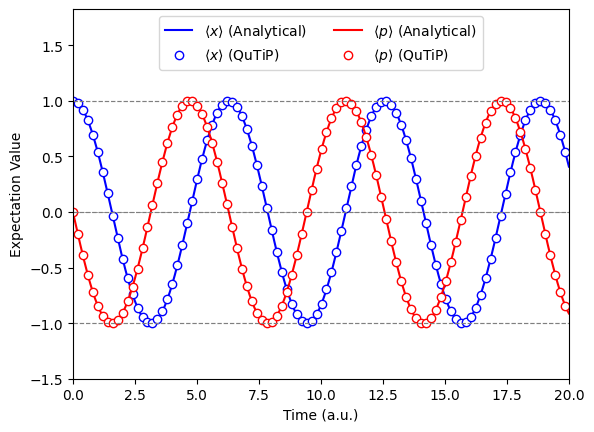

In [3]:
import matplotlib.pyplot as plt

# Operators for position and momentum
X_op = (a.dag() + a) / np.sqrt(2)
P_op = 1j * (a.dag() - a) / np.sqrt(2)

# Compute numerical expectation values
exp_x_qt = qt.expect(X_op, result.states)
exp_p_qt = qt.expect(P_op, result.states)

# Analytical results
exp_x_ana = [x_0*np.cos(omega*t) + (p_0/mass/omega)*np.sin(omega*t) for t in tlist]
exp_p_ana = [-mass*omega*x_0*np.sin(omega*t) + p_0*np.cos(omega*t) for t in tlist]

# Plot
fig, ax = plt.subplots()
ax.plot(tlist, exp_x_ana, '-', color='blue',
        label=r'$\langle x \rangle$ (Analytical)')
ax.plot(tlist, exp_x_qt, 'o', color='blue',
        label=r'$\langle x \rangle$ (QuTiP)',
        markeredgecolor='blue', markevery=4,
        fillstyle='full', markerfacecolor='white')
ax.plot(tlist, exp_p_ana, '-', color='red',
        label=r'$\langle p \rangle$ (Analytical)')
ax.plot(tlist, exp_p_qt, 'o', color='red',
        label=r'$\langle p \rangle$ (QuTiP)',
        markeredgecolor='red', markevery=4,
        fillstyle='full', markerfacecolor='white')
ax.axhline(0, ls='--', lw=0.5, color='black', alpha=0.5)
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('Expectation Value')
plt.legend(loc='upper center', ncol=2)
ax.set_ylim(-1.5, 1.825)
plt.hlines([-1, 0, 1], min(tlist), max(tlist),
           ls='--', lw=0.85, color='tab:grey', zorder=2)
ax.set_xlim(min(tlist), max(tlist))

plt.savefig('qflux_I_figure_3.tiff', dpi=300, format='tiff')
plt.show()


# Section 3

## Script S.3.1: Coherent State Wavepacket Initialization <a name="ScriptSpt3pt1"></a>

In [4]:
import numpy as np

def get_xgrid(xmin, xmax, N_pts):
    """Generate an evenly spaced position grid."""
    dx = (xmax - xmin)/N_pts
    xgrid = np.arange(-N_pts/2, N_pts/2)*dx
    return xgrid

def get_pgrid(xmin, xmax, N_pts, reorder=True):
    """Generate a momentum grid using FFT-compatible ordering."""
    dp = 2 * np.pi / (xmax-xmin)
    pmin = -dp * N_pts / 2
    pmax = dp * N_pts / 2
    plus_pgrid = np.linspace(0, pmax, N_pts//2+1)
    minus_pgrid = - np.flip(np.copy(plus_pgrid))
    if reorder:
        pgrid = np.concatenate((plus_pgrid[:-1], minus_pgrid[:-1]))
    else:
        pgrid = np.concatenate((minus_pgrid, plus_pgrid))
    return pgrid

def get_coherent_state(x, p_0, x_0, mass=1, omega=1, hbar=1):
    """Generate an initial coherent state wavefunction."""
    normalization = (mass*omega/np.pi/hbar)**(0.25)
    y = normalization*np.exp(
        -1*(mass*omega/hbar/2)*((x-x_0)**2) + 1j*p_0*x/hbar
    )
    return y

xmin = -7.0
xmax = 7.0
N_pts = 128
mass = 1.0  # mass in atomic units
omega = 1.0  # oscillator frequency
xgrid = get_xgrid(xmin, xmax, N_pts)
dx = xgrid[1] - xgrid[0]
pgrid = get_pgrid(xmin, xmax, N_pts, reorder=True)

x_0 = 1.0
p_0 = 0.0
psi_0 = get_coherent_state(xgrid, p_0, x_0, mass, omega)


## Script S.3.2: SOFT Operators For Harmonic Oscillator <a name="ScriptSpt3pt2"></a>

In [5]:
import numpy as np

def get_harmonic_potential(x, x_0=0.0, mass=1, omega=1):
    return mass * omega**2 * (x - x_0)**2 / 2

def get_kinetic_energy(p, mass=1):
    return p**2 / (2 * mass)

Vx_harm = get_harmonic_potential(xgrid)
K_harm = get_kinetic_energy(pgrid, mass)


## Script S.3.3: SOFT Propagation <a name="ScriptSpt3pt3"></a>

In [6]:
import numpy as np

def get_propagator_on_grid(operator_grid, tau, hbar=1):
    return np.exp(-1.0j * operator_grid * tau / hbar)

def do_SOFT_propagation(psi, K_prop, V_prop):
    psi_t_position_grid = V_prop * psi
    psi_t_momentum_grid = K_prop * np.fft.fft(psi_t_position_grid, norm="ortho")
    psi_t = V_prop * np.fft.ifft(psi_t_momentum_grid, norm="ortho")
    return psi_t

tmin, tmax, N_tsteps = 0.0, 20.0, 400
tgrid = np.linspace(tmin, tmax, N_tsteps)
tau = tgrid[1] - tgrid[0]

V_prop = get_propagator_on_grid(Vx_harm/2, tau)
K_prop = get_propagator_on_grid(K_harm, tau)

propagated_states_harm = [psi_0]
psi_t = psi_0
for _ in range(len(tgrid)):
    psi_t = do_SOFT_propagation(psi_t, K_prop, V_prop)
    propagated_states_harm.append(psi_t)

propagated_states_harm = np.asarray(propagated_states_harm)[:-1]


## Script S.3.4: Harmonic Oscillator Expectation Values <a name="ScriptSpt3pt4"></a>

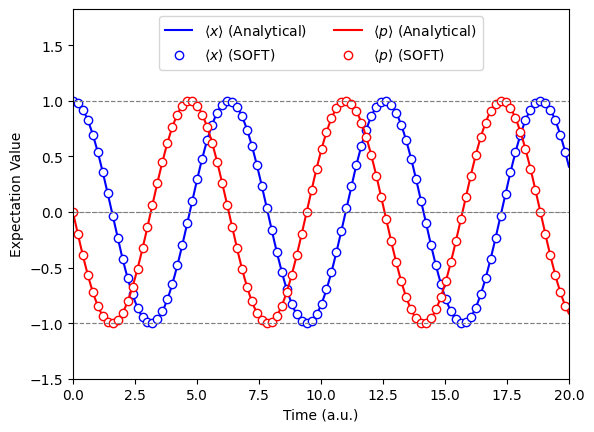

In [7]:
def position_expectation_value(xgrid, psi):
    dx = xgrid[1]-xgrid[0]
    return dx*np.real(np.sum(xgrid * np.conjugate(psi) * psi))

def momentum_expectation_value(dx, pgrid, psi):
    psip = np.fft.fft(psi)
    return dx*np.real(np.sum(pgrid * np.conjugate(psip) * psip))/len(psi)

avx_soft = [position_expectation_value(xgrid, propagated_states_harm[i])
            for i in range(len(propagated_states_harm))]
dx = xgrid[1]-xgrid[0]
avp_soft = [momentum_expectation_value(dx, pgrid, propagated_states_harm[i])
            for i in range(len(propagated_states_harm))]

avx_ana = [x_0*np.cos(omega*t) + (p_0/mass/omega)*np.sin(omega*t)
           for t in tgrid]
avp_ana = [-x_0*omega*mass*np.sin(omega*t) + p_0*np.cos(omega*t)
           for t in tgrid]

# Plot
fig, ax = plt.subplots()
ax.plot(tlist, avx_ana, '-', color='blue',
        label=r'$\langle x \rangle$ (Analytical)')
ax.plot(tlist, avx_soft, 'o', color='blue',
        label=r'$\langle x \rangle$ (SOFT)',
        markeredgecolor='blue', markevery=4,
        fillstyle='full', markerfacecolor='white')
ax.plot(tlist, avp_ana, '-', color='red',
        label=r'$\langle p \rangle$ (Analytical)')
ax.plot(tlist, avp_soft, 'o', color='red',
        label=r'$\langle p \rangle$ (SOFT)',
        markeredgecolor='red', markevery=4,
        fillstyle='full', markerfacecolor='white')
ax.axhline(0, ls='--', lw=0.5, color='black', alpha=0.5)
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('Expectation Value')
plt.legend(loc='upper center', ncol=2)
ax.set_ylim(-1.5, 1.825)
plt.hlines([-1, 0, 1], min(tlist), max(tlist),
           ls='--', lw=0.85, color='tab:grey', zorder=2)
ax.set_xlim(min(tlist), max(tlist))

plt.savefig('qflux_I_figure_4.tiff', dpi=300, format='tiff')
plt.show()


# Section 4

## Script S.4.1: QFlux Installation <a name="ScriptSpt4pt1"></a>

In [ ]:
!pip install qflux[gqme]

In [8]:
from qflux.GQME.tt_tfd import *
from qflux.GQME.tdvp import _tdvp1
from qflux.GQME.tt_utils import *
from __future__ import annotations

import matplotlib.pyplot as plt

SPIN-BOSON Model parameter
        epsilon = 1
             xi = 0.1
        omega_c = 2
      omega_max = 10
     time steps = 500
             DT = 0.00600331998021117
     final time = 3.001659990105585
          DOF_E = 2
          DOF_N = 50


## Script S.4.2: Model Parameters <a name="ScriptSpt4pt2"></a>

In [9]:
class Params:
    def __init__(self):
        # ==== Spin-Boson Model parameters ====
        self.GAMMA_DA = 1          # diabatic coupling
        self.EPSILON  = 1
        self.BETA     = 5          # inverse temperature beta = 1 / (k_B * T)
        self.XI       = 0.1
        self.OMEGA_C  = 2

        # Spin-up and spin-down states
        self.spin_up   = np.array([1.0, 0.0], dtype=np.float64)
        self.spin_down = np.array([0.0, 1.0], dtype=np.float64)

        # ==== General constants for simulation ====
        self.TIME_STEPS = 500                    # number of time steps
        self.au2ps      = 0.00002418884254       # as -> a.u. conversion
        self.timeau     = 12.409275
        self.DT         = 20 * self.au2ps * self.timeau  # time step in au

        self.FINAL_TIME = self.TIME_STEPS * self.DT
        self.DOF_E      = 2                      # number of electronic states
        self.DOF_E_SQ   = self.DOF_E * self.DOF_E

        # ==== Simulation parameters for TT-TFD ====
        self.DOF_N      = 50     # number of nuclear DOF
        self.OMEGA_MAX  = 10

        # TT constants
        self.eps         = 1e-12         # tt approx error
        self.dim         = self.DOF_N    # number of coords
        self.occ         = 10            # max occupation number
        self.MAX_TT_RANK = 10

        # ==== Simulation parameters for GQME ====
        self.MEM_TIME          = self.DT * self.TIME_STEPS
        self.HBAR              = 1
        self.MAX_ITERS         = 30
        self.CONVERGENCE_PARAM = 10.0**(-10.0)

        # ==== Parameter string for output files ====
        self.PARAM_STR  = "_Spin-Boson_Ohmic_TT-TFD_b%sG%s_e%s_" % (
            self.BETA, self.GAMMA_DA, self.EPSILON
        )
        self.PARAM_STR += "xi%swc%s_wmax%s_dofn%s" % (
            self.XI, self.OMEGA_C, self.OMEGA_MAX, self.DOF_N
        )

        # ==== Pauli matrices ====
        self.X = np.array([[0, 1], [1, 0]], dtype=np.complex128)
        self.Y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
        self.Z = np.array([[1, 0], [0, -1]], dtype=np.complex128)
        self.I = np.eye(2, dtype=np.complex128)

# create a global instance, so you can do: pp.xx
pp = Params()


## Script S.4.3: TT-TFD Simulation Of Spin-Boson Model <a name="ScriptSpt4pt3"></a>

In [10]:
def tt_initial_state(istate: int) -> MPS:
    """
    Initialize the state in tensor-train (MPS) format for a TT-TFD calculation.

    Parameters
    ----------
    istate : int
        Type of initial electronic state:
        0 : spin-up
        1 : (spin-up + spin-down) / sqrt(2)
        2 : (spin-up + i * spin-down) / sqrt(2)
        3 : spin-down

    Returns
    -------
    MPS
        Initialized MPS with the chosen electronic state at the first site
        and vacuum/ground states on the remaining sites.
        QFlux uses mpsqd https://github.com/qiangshi-group/MPSQD
    """
    # Sanity check on istate
    if istate not in (0, 1, 2, 3):
        raise ValueError(f"Invalid istate={istate}. Must be in {{0, 1, 2, 3}}.")

    # -------------------------------------------------------------------------
    # Define single-site electronic tensors
    # -------------------------------------------------------------------------
    su = np.zeros((1, pp.DOF_E, pp.MAX_TT_RANK), dtype=np.complex128)
    sd = np.zeros((1, pp.DOF_E, pp.MAX_TT_RANK), dtype=np.complex128)

    su[0, :, 0] = pp.spin_up
    sd[0, :, 0] = pp.spin_down

    # Superpositions
    inv_sqrt2 = 1.0 / np.sqrt(2.0)
    e1 = inv_sqrt2 * (su + sd)
    e2 = inv_sqrt2 * (su + 1j * sd)

    # Select the initial electronic core
    electronic_cores = {
        0: su,
        1: e1,
        2: e2,
        3: sd,
    }
    first_core = electronic_cores[istate]

    # -------------------------------------------------------------------------
    # Build MPS structure
    # -------------------------------------------------------------------------
    # nbarr: local dimensions for each site
    num_sites = 1 + 2 * pp.DOF_N
    nbarr = np.full(num_sites, pp.occ, dtype=int)
    nbarr[0] = pp.DOF_E  # first site is electronic

    y0 = MPS(num_sites, nb=nbarr)
    y0.nodes.append(first_core)

    # Middle sites: identity-like / vacuum cores
    middle_core = np.zeros(
        (pp.MAX_TT_RANK, pp.occ, pp.MAX_TT_RANK),
        dtype=np.complex128
    )
    middle_core[0, 0, 0] = 1.0

    # Append 2 * DOF_N - 1 middle cores
    for _ in range(2 * pp.DOF_N - 1):
        y0.nodes.append(middle_core)

    # Last site: right boundary core with rank-1 right bond
    last_core = np.zeros(
        (pp.MAX_TT_RANK, pp.occ, 1),
        dtype=np.complex128
    )
    last_core[0, 0, 0] = 1.0
    y0.nodes.append(last_core)

    return y0


In [11]:
# ---- user choices for the test ----
initial_state = 0       # 0: |up>, 1: (|up>+|down>)/sqrt2, etc.
update_type   = "rk4"   # "rk4" or "krylov"
rk4slices     = 1       # only used if update_type == "rk4"
mmax          = 4       # only used if update_type == "krylov"
verbose       = True
show_steptime = True

# ---- run simulation ----
print("Building initial state and Hamiltonian")
y0 = tt_initial_state(initial_state)
A  = tt_hamiltonian(eps=pp.eps, pp=pp)

print("Propagating")
Is_qflux_tt_tfd = True
if Is_qflux_tt_tfd:
    t, RDO_arr = tt_tfd(initial_state=0, show_steptime=True, update_type='rk4')
else:
    t, RDO_arr = tt_ksl_propagator(
        y0,
        A,
        update_type=update_type,
        rk4slices=rk4slices,
        mmax=mmax,
        RDO_arr_bench=None,
        property_fn=cal_property,
        verbose=verbose,
        show_steptime=show_steptime,
        copy_state=False,   # set True if you want to keep `y0` unchanged
        pp=pp,
        )

print("Propagation finished.")
print("RDO_arr shape:", RDO_arr.shape)


Building initial state and Hamiltonian
Propagating
Start doing propagation
0 0.0
timefor tdvp: 0.06714773178100586
1 0.00600331998021117
timefor tdvp: 0.068695068359375
2 0.01200663996042234
timefor tdvp: 0.0690610408782959
3 0.01800995994063351
timefor tdvp: 0.06991982460021973
4 0.02401327992084468
timefor tdvp: 0.06865310668945312
5 0.03001659990105585
timefor tdvp: 0.0690770149230957
6 0.03601991988126702
timefor tdvp: 0.07095885276794434
7 0.04202323986147819
timefor tdvp: 0.06872797012329102
8 0.04802655984168936
timefor tdvp: 0.0688931941986084
9 0.05402987982190053
timefor tdvp: 0.07051706314086914
10 0.0600331998021117
timefor tdvp: 0.06937694549560547
11 0.06603651978232288
timefor tdvp: 0.06893706321716309
12 0.07203983976253404
timefor tdvp: 0.07025527954101562
13 0.07804315974274521
timefor tdvp: 0.0684669017791748
14 0.08404647972295638
timefor tdvp: 0.06942200660705566
15 0.09004979970316755
timefor tdvp: 0.07007431983947754
16 0.09605311968337872
timefor tdvp: 0.0688030

## Script S.4.4: Extract And Plot Populations And Coherences <a name="ScriptSpt4pt4"></a>

In [ ]:
import matplotlib.pyplot as plt

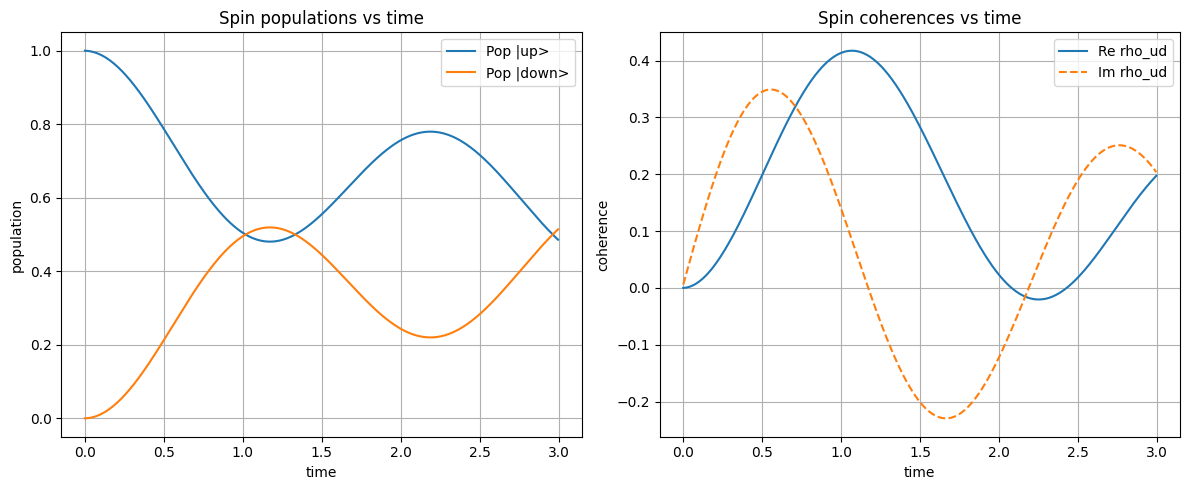

In [15]:
# RDO_arr: shape (TIME_STEPS, 4) for a 2-level system
pop_up   = RDO_arr[:, 0].real
pop_down = RDO_arr[:, 3].real
coh_ud   = RDO_arr[:, 1]  # complex

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ---- population plot ----
ax1.plot(t, pop_up,   label="Pop |up>")
ax1.plot(t, pop_down, label="Pop |down>")
ax1.set_xlabel("time")
ax1.set_ylabel("population")
ax1.legend()
ax1.set_title("Spin populations vs time")
ax1.grid(True)

# ---- coherence plot ----
ax2.plot(t, coh_ud.real, label="Re rho_ud")
ax2.plot(t, coh_ud.imag, label="Im rho_ud", linestyle="--")
ax2.set_xlabel("time")
ax2.set_ylabel("coherence")
ax2.legend()
ax2.set_title("Spin coherences vs time")
ax2.grid(True)

fig.tight_layout()
plt.savefig('qflux_I_figure_5.tiff', dpi=300, format='tiff')
plt.show()


## Script S.4.5: State Initialization <a name="ScriptSpt4pt5"></a>

In [16]:
def tt_initial_state(istate: int) -> MPS:
    """
    Initialize the state in tensor-train (MPS) format for a TT-TFD calculation.

    Parameters
    ----------
    istate : int
        Type of initial electronic state:
        0 : spin-up
        1 : (spin-up + spin-down) / sqrt(2)
        2 : (spin-up + i * spin-down) / sqrt(2)
        3 : spin-down

    Returns
    -------
    MPS
        Initialized MPS with the chosen electronic state at the first site
        and vacuum/ground states on the remaining sites.
        QFlux uses mpsqd https://github.com/qiangshi-group/MPSQD
    """
    # Sanity check on istate
    if istate not in (0, 1, 2, 3):
        raise ValueError(f"Invalid istate={istate}. Must be in {{0, 1, 2, 3}}.")

    # -------------------------------------------------------------------------
    # Define single-site electronic tensors
    # -------------------------------------------------------------------------
    su = np.zeros((1, pp.DOF_E, pp.MAX_TT_RANK), dtype=np.complex128)
    sd = np.zeros((1, pp.DOF_E, pp.MAX_TT_RANK), dtype=np.complex128)

    su[0, :, 0] = pp.spin_up
    sd[0, :, 0] = pp.spin_down

    # Superpositions
    inv_sqrt2 = 1.0 / np.sqrt(2.0)
    e1 = inv_sqrt2 * (su + sd)
    e2 = inv_sqrt2 * (su + 1j * sd)

    # Select the initial electronic core
    electronic_cores = {
        0: su,
        1: e1,
        2: e2,
        3: sd,
    }
    first_core = electronic_cores[istate]

    # -------------------------------------------------------------------------
    # Build MPS structure
    # -------------------------------------------------------------------------
    # nbarr: local dimensions for each site
    num_sites = 1 + 2 * pp.DOF_N
    nbarr = np.full(num_sites, pp.occ, dtype=int)
    nbarr[0] = pp.DOF_E  # first site is electronic

    y0 = MPS(num_sites, nb=nbarr)
    y0.nodes.append(first_core)

    # Middle sites: identity-like / vacuum cores
    middle_core = np.zeros(
        (pp.MAX_TT_RANK, pp.occ, pp.MAX_TT_RANK),
        dtype=np.complex128
    )
    middle_core[0, 0, 0] = 1.0

    # Append 2 * DOF_N - 1 middle cores
    for _ in range(2 * pp.DOF_N - 1):
        y0.nodes.append(middle_core)

    # Last site: right boundary core with rank-1 right bond
    last_core = np.zeros(
        (pp.MAX_TT_RANK, pp.occ, 1),
        dtype=np.complex128
    )
    last_core[0, 0, 0] = 1.0
    y0.nodes.append(last_core)

    return y0


## Script S.4.6: Bath Frequency Discretization <a name="ScriptSpt4pt6"></a>

In [17]:
def discretize_ohmic(freq_count: int):
    """
    Discretize an Ohmic spectral density into `freq_count` modes.

    Returns
    -------
    freq : (N,) array
    ck   : (N,) array
    gk   : (N,) array
    thetak, sinhthetak, coshthetak : (N,) arrays
    """
    N = freq_count

    om = pp.OMEGA_C / N * (1.0 - np.exp(-pp.OMEGA_MAX / pp.OMEGA_C))

    freq = np.zeros(N, dtype=float)
    ck = np.zeros(N, dtype=float)
    gk = np.zeros(N, dtype=float)
    thetak = np.zeros(N, dtype=float)
    sinhthetak = np.zeros(N, dtype=float)
    coshthetak = np.zeros(N, dtype=float)

    for i in range(N):
        freq[i] = -pp.OMEGA_C * np.log(
            1.0 - (i + 1) * om / pp.OMEGA_C
        )
        ck[i] = np.sqrt(pp.XI * om) * freq[i]
        gk[i] = -ck[i] / np.sqrt(2.0 * freq[i])

        th = np.arctanh(np.exp(-pp.BETA * freq[i] / 2.0))
        thetak[i] = th
        sinhthetak[i] = np.sinh(th)
        coshthetak[i] = np.cosh(th)

    return freq, ck, gk, thetak, sinhthetak, coshthetak


## Script S.4.7: Two-Level Hamiltonian <a name="ScriptSpt4pt7"></a>

In [18]:
def build_electronic_hamiltonian(epsilon: float, gamma_da: float):
    """2x2 electronic Hamiltonian in matrix form."""
    px = np.array([[0.0, 1.0],
                   [1.0, 0.0]], dtype=np.complex128)
    pz = np.array([[1.0, 0.0],
                   [0.0, -1.0]], dtype=np.complex128)
    return epsilon * pz + gamma_da * px


## Script S.4.8: Kronecker-Extend A 2X2 TT-Matrix With 2*Dof\_N Modes <a name="ScriptSpt4pt8"></a>

In [19]:
def tt_embed_electronic(tt_He, total_boson_modes: int, occ: int):
    """
    Kronecker-extend a 2x2 TT-matrix to include 2*DOF_N bosonic modes.
    """
    return tt_kron(tt_He, tt_eye(2 * total_boson_modes, occ))


## Script S.4.9: Number Operator <a name="ScriptSpt4pt9"></a>

In [20]:
def build_number_operator_local(occ: int):
    """Local harmonic number operator in matrix form."""
    return np.diag(np.arange(occ, dtype=np.complex128))


## Script S.4.10: Create A TT With Identity Structure <a name="ScriptSpt4pt10"></a>

In [21]:
def tt_zero_like_eye(num_sites: int, occ: int):
    """Create a TT with identity structure and then zero all cores."""
    tt_obj = tt_eye(num_sites, occ)
    for i in range(num_sites):
        tt_obj.nodes[i] *= 0.0
    return tt_obj


## Script S.4.11: Sum Local Operator <a name="ScriptSpt4pt11"></a>

In [22]:
def tt_sum_local_operators(num_sites: int,
                           occ: int,
                           local_mats,
                           site_coeffs,
                           eps: float):
    """
    Build sum_k site_coeffs[k] * (I ... x local_mats[k] x ... I) in TT form.
    """
    tt_total = tt_zero_like_eye(num_sites, occ)

    for k, (Mloc, coeff) in enumerate(zip(local_mats, site_coeffs)):
        tmp0 = tt_matrix(Mloc)
        tmp0.nodes[0] *= coeff

        if k == 0:
            tmp = tt_kron(tmp0, tt_eye(num_sites - 1, occ))
        elif k < num_sites - 1:
            tmp = tt_kron(tt_eye(k - 1, occ), tmp0)
            tmp = tt_kron(tmp, tt_eye(num_sites - k, occ))
        else:  # last site
            tmp = tt_kron(tt_eye(k, occ), tmp0)

        tt_total = add_tensor(tt_total, tmp, small=eps)

    return tt_total


## Script S.4.12: Local Displacement Operator $  x  $ <a name="ScriptSpt4pt12"></a>

In [23]:
def build_displacement_local(occ: int):
    """
    Local displacement operator (x operator) in HO basis.
    """
    D = np.zeros((occ, occ), dtype=np.complex128)
    for i in range(occ - 1):
        s = np.sqrt(i + 1.0)
        D[i, i + 1] = s
        D[i + 1, i] = s
    return D


## Script S.4.13: TT Representation Of $  \sum_k freq[k] a_k^\dagger a_k  $ <a name="ScriptSpt4pt13"></a>

In [24]:
def tt_number_operator_physical(freq, eps: float):
    r"""
    TT representation of sum_k freq[k] * a_k^\dagger a_k on DOF_N sites.
    """
    N = pp.DOF_N
    numoc = build_number_operator_local(pp.occ)
    local_mats = [numoc] * N
    return tt_sum_local_operators(N, pp.occ, local_mats, freq, eps)


## Script S.4.14: TT Representation Of $  \sum_k gk[k]\cosh(\theta_k) (a_k + a_k^\dagger)  $ <a name="ScriptSpt4pt14"></a>

In [25]:
def tt_displacement_physical(gk, coshthetak, eps: float):
    r"""
    TT representation of sum_k gk[k] cosh(theta_k) (a_k + a_k^\dagger)
    """
    N = pp.DOF_N
    D = build_displacement_local(pp.occ)
    local_mats = [D] * N
    coeffs = gk * coshthetak
    return tt_sum_local_operators(N, pp.occ, local_mats, coeffs, eps)


## Script S.4.15: TT Representation Of $  \sum_k gk[k] \sinh(\theta_k) (\tilde{a}_k + \tilde{a}_k^\dagger)  $ <a name="ScriptSpt4pt15"></a>

In [26]:
def tt_displacement_fictitious(gk, sinhthetak, eps: float):
    r"""
    TT representation of sum_k gk[k] sinh(theta_k) (tilde a_k + tilde a_k^\dagger)
    """
    N = pp.DOF_N
    D = build_displacement_local(pp.occ)
    local_mats = [D] * N
    coeffs = gk * sinhthetak
    return tt_sum_local_operators(N, pp.occ, local_mats, coeffs, eps)


## Script S.4.16: Lift A Bosonic TT Operator <a name="ScriptSpt4pt16"></a>

In [27]:
def tt_lift_to_system(tt_boson, system_op):
    """
    Lift a bosonic TT operator to include a 2D electronic system:

    result = system_op (x) tt_boson (x) I_boson (or variations).
    """
    tt_sys = tt_matrix(system_op)
    return tt_kron(tt_sys, tt_boson)


## Script S.4.17:  $  \text{left}_\text{op} \otimes \text{tt}_\text{boson} \otimes I$ <a name="ScriptSpt4pt17"></a>

In [28]:
def tt_lift_physical_with_fictitious(tt_boson, left_op, eps: float):
    """
    Construct (left_op (x) tt_boson (x) I).
    """
    tt_left = tt_matrix(left_op)
    tt = tt_kron(tt_left, tt_boson)
    tt = tt_kron(tt, tt_eye(pp.DOF_N, pp.occ))
    return tt


## Script S.4.18:  $  \text{left}_\text{op} \otimes I \otimes \text{tt}_\text{boson}  $ <a name="ScriptSpt4pt18"></a>

In [29]:
def tt_lift_fictitious_with_physical(tt_boson, left_op, eps: float):
    """
    Construct (left_op x I x tt_boson).
    """
    tt_left = tt_matrix(left_op)
    tt = tt_kron(tt_left, tt_eye(pp.DOF_N, pp.occ))
    tt = tt_kron(tt, tt_boson)
    return tt


## Script S.4.19: Build $  -\ii H  $ for the TFD Spin--Boson Model <a name="ScriptSpt4pt19"></a>

In [30]:
def tt_hamiltonian(eps: float = 1e-14):
    """
    Build -iH for the TFD spin-boson model using modular building blocks.

    Returns
    -------
    MPO (MPS-like TT object)
    """
    # --- parameters ---
    freq, ck, gk, thetak, sinhthetak, coshthetak = discretize_ohmic(pp.DOF_N)

    # --- electronic part ---
    He = build_electronic_hamiltonian(pp.EPSILON, pp.GAMMA_DA)
    tt_He = tt_matrix(He)
    tt_He = tt_embed_electronic(tt_He, pp.DOF_N, pp.occ)

    # --- physical and fictitious number operators ---
    tt_num_physical = tt_number_operator_physical(freq, eps)
    tt_Ie = tt_matrix(np.eye(2, dtype=np.complex128))

    tt_systemnumoc = tt_kron(tt_Ie, tt_num_physical)
    tt_systemnumoc = tt_kron(tt_systemnumoc, tt_eye(pp.DOF_N, pp.occ))

    tt_tildenumoc = tt_kron(tt_Ie, tt_eye(pp.DOF_N, pp.occ))
    tt_tildenumoc = tt_kron(tt_tildenumoc, tt_num_physical)

    # --- displacement operators ---
    tt_energy = tt_displacement_physical(gk, coshthetak, eps)
    tt_systemenergy = tt_kron(tt_matrix(np.array([[1, 0], [0, -1]],
                                                 dtype=np.complex128)),
                              tt_energy)
    tt_systemenergy = tt_kron(tt_systemenergy, tt_eye(pp.DOF_N, pp.occ))

    tt_tilenergy = tt_displacement_fictitious(gk, sinhthetak, eps)
    tt_tildeenergy = tt_kron(tt_matrix(np.array([[1, 0], [0, -1]],
                                                dtype=np.complex128)),
                             tt_eye(pp.DOF_N, pp.occ))
    tt_tildeenergy = tt_kron(tt_tildeenergy, tt_tilenergy)

    # --- assemble H ---
    H = add_tensor(tt_He, tt_systemnumoc, small=eps)
    H = add_tensor(H, tt_tildenumoc, coeff=-1.0, small=eps)
    H = add_tensor(H, tt_systemenergy, coeff=1.0, small=eps)
    H = add_tensor(H, tt_tildeenergy, coeff=1.0, small=eps)

    # fold -i into the first core
    H.nodes[0] *= -1j

    # convert to MPO and truncate
    A = MPS2MPO(H).truncation(small=eps)
    return A


## Script S.4.20: TT-KSL Runge-Kutta Linear Solver <a name="ScriptSpt4pt20"></a>

In [31]:
def tt_ksl_propagator(
    y0: Any,
    A: Any,
    update_type: str = "rk4",
    rk4slices: int = 1,
    mmax: int = 4,
    RDO_arr_bench: np.ndarray | None = None,
    property_fn: Callable[[Any], np.ndarray] = cal_property,
    verbose: bool = True,
    show_steptime: bool = False,
    copy_state: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Perform TT-TFD time propagation with a given initial state and Hamiltonian.

    Parameters
    ----------
    y0
        Initial TT/MPS state. If ``copy_state`` is False, this object is
        updated in-place by the propagator.
    A
        TT/MPO representing the (possibly non-Hermitian) generator, e.g. -iH.
    update_type : {"rk4", "krylov"}, optional
        Local time-stepper used in tdvp1site. Default is "rk4".
    rk4slices : int, optional
        Number of sub-slices for RK4 integration. Ignored for "krylov".
    mmax : int, optional
        Krylov subspace dimension for "krylov" updates. Default is 4.
    RDO_arr_bench : np.ndarray, optional
        Optional benchmark reduced density operator array of shape
        (TIME_STEPS, DOF_E_SQ). If provided, each step's RDO is compared
        with this reference via compare_diff.
    property_fn : callable, optional
        Function mapping the TT/MPS state to a (flattened) RDO array of shape
        (DOF_E_SQ,). Default is cal_property.
    verbose : bool, optional
        If True, print high-level progress information.
    show_steptime : bool, optional
        If True, print wall-clock time for each TDVP step.
    copy_state : bool, optional
        If True, work on a copy of `y0` instead of modifying it in-place.

    Returns
    -------
    t : np.ndarray
        1D array of simulation times of length pp.TIME_STEPS.
    RDO_arr : np.ndarray
        2D array of reduced density matrices over time with shape
        (pp.TIME_STEPS, pp.DOF_E_SQ).
    """
    n_steps = pp.TIME_STEPS
    dt = pp.DT

    # Optional copy so caller can keep original y0
    if copy_state and hasattr(y0, "copy"):
        y = y0.copy()
    else:
        y = y0

    RDO_arr = np.zeros((n_steps, pp.DOF_E_SQ), dtype=np.complex128)
    t = np.linspace(0.0, (n_steps - 1) * dt, n_steps, dtype=float)

    start_time = time.time()
    if verbose:
        print("Start propagation")
        print(f"  steps = {n_steps}, dt = {dt}, update_type = {update_type}")

    for ii, ti in enumerate(t):
        if verbose:
            print(f"Step {ii:6d}, t = {ti:.6f}")

        step_t0 = time.time()

        # TDVP one-site update
        y = tdvp1site(
            y,
            A,
            dt,
            update_type=update_type,
            mmax=mmax,
            rk4slices=rk4slices,
        )

        # Reduced density operator (or whatever property_fn returns)
        RDO_arr[ii] = property_fn(y)

        # Optional benchmark comparison
        if RDO_arr_bench is not None:
            compare_diff(RDO_arr[ii], RDO_arr_bench[ii])

        if show_steptime:
            print("  time for tdvp:", time.time() - step_t0)

    if verbose:
        print("\tTotal propagation time:", time.time() - start_time)

    return t, RDO_arr
